In [14]:
import jax 
import jax.numpy as jnp
import numpy as np

from jax.typing import ArrayLike
from typing import NamedTuple

import matplotlib.pyplot as plt

import flax.nnx as nnx

from probjax.nn.nets.transformer import  Transformer
from probjax.nn import MLP

from models import EDM, Simformer

In [15]:
mlp = MLP([1,10,10,1], rngs=nnx.Rngs(jax.random.PRNGKey(0)))

mlp_def, mlp_params = nnx.split(mlp)

In [16]:
params_list, tree = jax.tree_util.tree_flatten(mlp_params)
dims_by_id = {i:int(np.prod(x.shape)) for i,x in enumerate(params_list)}

In [17]:
params_flat, unflatten = jax.flatten_util.ravel_pytree(mlp_params)

In [18]:
NUM_PARAMS = len(params_flat)
NUM_PARAMS

141

In [19]:
def generate_data(rng):
    #x = jax.random.uniform(rng, (10,1), minval=-10, maxval=10)
    x = jnp.linspace(-3,3,50).reshape(-1,1)
    params = jax.random.normal(rng, (NUM_PARAMS,))
    _params = jax.scipy.stats.norm.cdf(params)*2 - 1
    params_unravel = unflatten(_params)
    mlp = nnx.merge(mlp_def, params_unravel)
    y = mlp(x)
    y += jax.random.normal(rng, y.shape) * 0.5
    data = jnp.concatenate([x, y], axis=-1)
    return params, data.reshape(-1)

-4.0032053


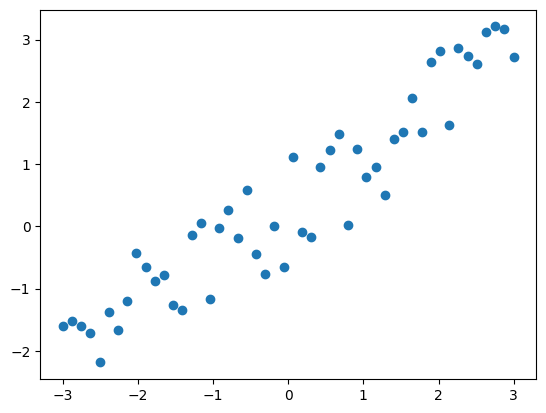

In [20]:
params, data = generate_data(jax.random.PRNGKey(5))
print(params.sum())
plt.plot(data[::2], data[1::2], 'o')

In [21]:
def log_posterior(params, data):
    params_ = jax.scipy.stats.norm.cdf(params)*2-1
    mlp_params = unflatten(params_)
    mlp = nnx.merge(mlp_def, mlp_params)
    x = data[::2,None]
    y = data[1::2,None]
    y_pred = mlp(x)
    log_likelihood = jax.scipy.stats.norm.logpdf(y, y_pred, .5).sum()
    log_prior = -0.5 * jnp.dot(params, params)
    return jnp.sum(log_likelihood + log_prior)

def score_fn(params, data):
    return jax.grad(log_posterior)(params, data)


score_fn(params, data)

Array([  5.726,  -4.581,   0.557,   3.118,  -3.45 ,   2.334,  -1.519,
         2.437,  -7.242,  -2.624,   6.693, -13.727,  -0.936,   3.391,
         2.19 ,  -0.568,   8.997,   1.53 ,   5.112,   8.044,   1.772,
         3.454,   1.654,  -0.484,   7.757,   1.811,  -8.421,   0.786,
        -7.065,   5.312,   5.477,  -0.225,   0.365,   5.14 ,   1.043,
         1.738,  -6.011,   1.206,   1.943,  -0.37 ,   1.775,   2.673,
        -3.098,   2.247,   4.674,   1.708,  -3.465,   0.693,  -3.309,
         2.486,   0.6  ,   1.991,  -1.796,   1.484,   1.596,  -1.096,
         0.687,   0.538,  -0.65 ,  -1.214,  -1.4  ,   0.795,  -0.319,
         0.545,  -1.71 ,   1.416,  -0.692,  -0.589,   0.871,  -1.13 ,
         1.43 ,  -0.301,  -0.537,   0.175,   0.543,   0.111,   1.471,
        -1.522,  -1.314,   1.013,   0.345,   1.618,   0.226,   1.845,
         1.463,  -0.499,  -0.414,  -1.153,   1.06 ,   2.223,   1.646,
         2.513,  -0.771,   0.392,   1.707,   0.803,  -0.543,  -0.029,
        -2.023,   0.

In [22]:
from functools import partial
from probjax.nn import GaussianFourierEmbedding

class Model(nnx.Module, experimental_pytree=True):

    hidden_dim = 100
    num_layers = 6

    def __init__(self, in_dim, context_dim, rngs):
        self.in_dim = in_dim
        hidden_dim = self.hidden_dim
        num_layers = self.num_layers
        self.context_net = MLP([context_dim,500,200,100], rngs=rngs)
        self.time_net = GaussianFourierEmbedding(1,hidden_dim, rngs=rngs, learnable=True)
        self.in_layer = nnx.Linear(in_dim + 100, hidden_dim, rngs=rngs)
        self.out_layer = nnx.Linear(hidden_dim, in_dim, rngs=rngs)
        self.out_layer2 = nnx.Linear(hidden_dim, in_dim, rngs=rngs)
        self.hidden_layers = [nnx.Linear(hidden_dim,hidden_dim, rngs=rngs) for _ in range(num_layers)]
        self.hidden_layer_norms = [nnx.LayerNorm(hidden_dim, rngs=rngs) for _ in range(num_layers)]
        self.layer_norm1 = nnx.LayerNorm(in_dim+100, rngs=rngs)
        self.layer_norm2 = nnx.LayerNorm(in_dim, rngs=rngs)
        self.rngs = rngs

    def __call__(self, t, x, context):
        context_new = self.context_net(context)
        time = self.time_net(t)
        inp = jnp.concatenate([x, context_new], axis=-1)
        inp = self.layer_norm1(inp)
        h = self.in_layer(inp)
        for i in range(self.num_layers):
            h = self.hidden_layer_norms[i](h)
            h += time
            h = jax.nn.relu(h)
            h = self.hidden_layers[i](h) + h
           
            
        out = self.out_layer(h)
        out = self.layer_norm2(out)
        out2 = self.out_layer2(h)
        if len(x.shape) > 1:
            _score_fn = jax.vmap(score_fn)
        else:
            _score_fn = score_fn

        return jnp.exp(4*t)*_score_fn(x/model.c_in(jnp.exp(4*t)), context) * jax.nn.sigmoid(3+out2) + out



In [23]:
thetas, datas = jax.vmap(generate_data)(jax.random.split(jax.random.key(0), 100))
eps = jax.random.normal(jax.random.key(0), shape=thetas.shape)

In [24]:
net = Model(NUM_PARAMS, 100, nnx.Rngs(jax.random.PRNGKey(0)))
model = EDM(net)

graphdef, params, state = nnx.split(model, nnx.Param, nnx.Variable)

In [25]:
model.c_skip(0.01)

Array([1.], dtype=float32, weak_type=True)

In [26]:
theta_tilde = thetas + eps*0.1

In [27]:
theta_mean = theta_tilde + 0.1**2*jax.vmap(score_fn)(theta_tilde, datas)

In [28]:
theta_mean - thetas

Array([[-0.205, -0.008, -0.023, ..., -0.071,  0.114, -0.114],
       [-0.057, -0.197,  0.077, ..., -0.001, -0.082, -0.013],
       [-0.077, -0.092, -0.073, ...,  0.058,  0.049, -0.152],
       ...,
       [-0.094,  0.002, -0.047, ..., -0.06 , -0.025,  0.007],
       [-0.09 , -0.075, -0.035, ..., -0.027, -0.338, -0.187],
       [-0.285, -0.037,  0.445, ...,  0.263, -0.004, -0.032]],      dtype=float32)

In [29]:
node_ids = tuple([0,1,2,3,4,5])

model(jnp.ones((100,1))*0.1, thetas + eps*0.1, context=datas) - thetas

Array([[-0.296, -0.019, -0.192, ..., -0.196,  0.24 ,  0.047],
       [-0.162, -0.158, -0.063, ..., -0.108,  0.01 ,  0.23 ],
       [-0.203, -0.09 , -0.235, ..., -0.057,  0.188,  0.102],
       ...,
       [-0.235,  0.022, -0.205, ..., -0.166,  0.074,  0.222],
       [-0.173, -0.091, -0.168, ..., -0.13 , -0.225,  0.007],
       [-0.349, -0.037,  0.304, ...,  0.102,  0.086,  0.184]],      dtype=float32)

In [30]:
def loss_fn(params, key, times=None):
    model = nnx.merge(graphdef, params, state)
    rng, rng_loss, rng_time = jax.random.split(key,3)
    thetas, datas = jax.vmap(generate_data)(jax.random.split(rng, 50))
    thetas = thetas.repeat(10, axis=0)
    datas = datas.repeat(10, axis=0)

    if times is None:
        logt = jax.random.normal(rng_time, shape=(500, 1)) * 1.2 - 1.2
        t = jnp.exp(logt) + 0.0001
    else:
        t = times
    

    theta_noisy = thetas + jax.random.normal(rng_loss, thetas.shape) * model.std_fn(t)
    denoised_thetas = model(t, theta_noisy, context=datas)
    weights = model.weight_fn(t)
    
    loss = weights[...,None]*(thetas - denoised_thetas)**2


    return loss.mean()

In [31]:
loss_fn(params, jax.random.PRNGKey(5))

Array(55288.566, dtype=float32)

In [32]:
import optax

optimizer = optax.chain(optax.adaptive_grad_clip(100.0), optax.adam(5e-3))
opt_state = optimizer.init(params)
key = jax.random.PRNGKey(1)

@jax.jit
def update(params, opt_state, key):
    loss, grads = jax.value_and_grad(loss_fn)(params, key)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [33]:
model.c_out(.1)

Array([0.1], dtype=float32, weak_type=True)

In [34]:

for i in range(50_000):
    key, subkey = jax.random.split(key)
    params, opt_state, loss = update(params, opt_state, subkey)
    if i % 1000 == 0:
        print(loss)

675824.3
0.9944681
1.0086441
0.993602
0.99346614
0.9913451
0.999977
0.9876861
1.0015788
0.99346966
0.9994362
0.9942775
0.99944293
0.9984854
0.9924495
1.0046935
1.005678
1.002707
0.9996841
0.9942803
0.9934197
1.0058131
1.0026158
0.9931004
0.99658316
0.993481
0.99688035
0.9975856
0.99991137
1.0012739
0.9976011
1.0047033
1.0022008
0.98750204
0.99963635
0.99952316
1.009362
1.0065029
1.0045248
0.9960984
0.9879287


KeyboardInterrupt: 

In [35]:
model = nnx.merge(graphdef, params, state)

In [36]:
from probjax.utils.odeint import odeint
from probjax.utils.sdeint import sdeint

def naive_diffusion_sampling(key, x_o):
    
    T_end = 5.
    rng_init, rng_solve = jax.random.split(key)
    eps = jax.random.normal(rng_init, (NUM_PARAMS,)) * model.marginal_std(T_end)
    ts = jnp.linspace(0.0001, T_end, 1000)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        x_ = x.reshape((NUM_PARAMS,))
        f = model.drift(t,x_)
        g = model.diffusion(t, x_)
        score = model.score(t,x_, context=x_o)
        backward_f = (f -g**2*score).reshape(x.shape)
        return backward_f
    
    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        x_ = x.reshape((NUM_PARAMS,))
        g = model.diffusion(t, x_) * jnp.ones((NUM_PARAMS,))
        return g.reshape(x.shape)

    return sdeint(rng_solve,drift,diffusion, eps,ts[::-1], noise_type="diagonal")[-1]

In [37]:
theta, x_o = generate_data(jax.random.PRNGKey(1))

In [38]:
samples = jax.vmap(lambda k: naive_diffusion_sampling(k, x_o))(jax.random.split(jax.random.PRNGKey(0), 100))

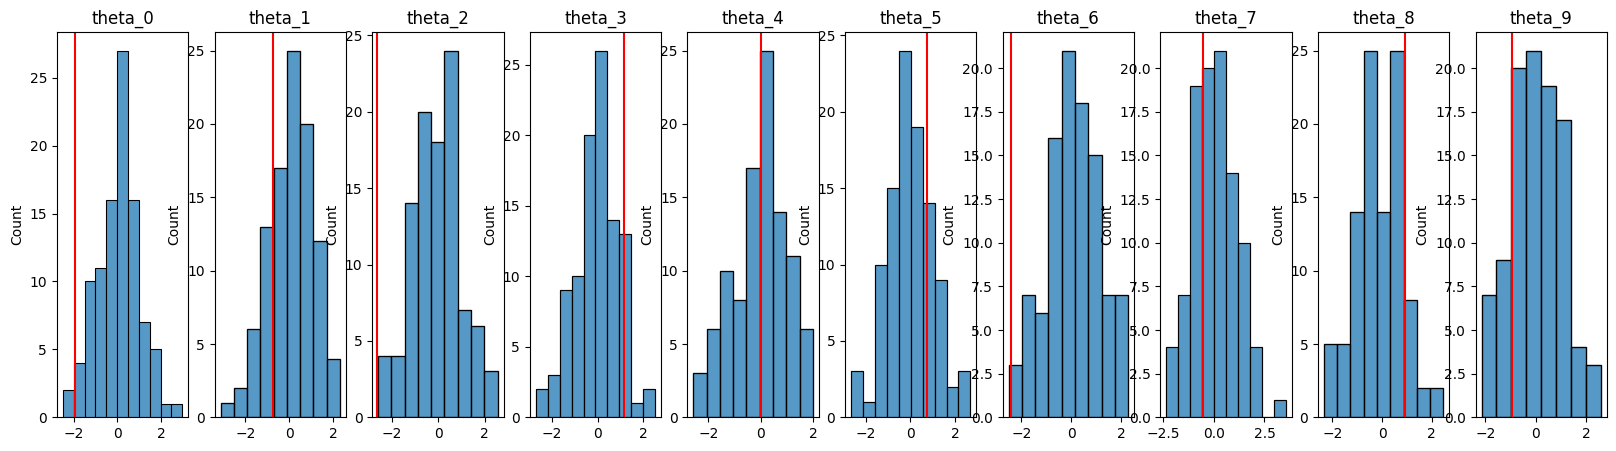

In [39]:
import seaborn as sns
import pandas as pd

fig, axes = plt.subplots(1,10, figsize=(20,5))
for i, ax in enumerate(axes):
    sns.histplot(samples[:,i], ax=ax)
    ax.axvline(theta[i], color='red')
    ax.set_title(f"theta_{i}")

In [40]:
def pred(params, x):
    params = jax.scipy.stats.norm.cdf(params)*6 - 3
    unflat_params = unflatten(params)
    mlp = nnx.merge(mlp_def, unflat_params)
    return mlp(x)

In [41]:
ys = jax.vmap(lambda p: pred(p, x_o[::2, None]))(samples)

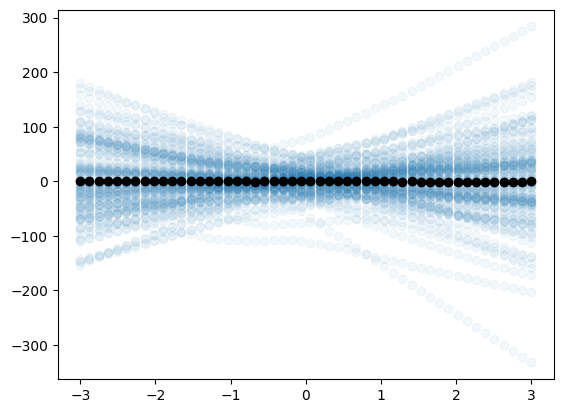

In [42]:
_ = plt.plot(x_o[::2], ys[:,:,0].T, 'o', color="C0", alpha=0.05)
plt.plot(x_o[::2], x_o[1::2], 'o', color="black")